In [1]:
!pip install solara
!pip install mesa

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 46.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.8/108.8 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.9/268.9 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.5/71.5 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 42.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.1/275.1 kB 6.0 MB/s eta 0:00:00


In [2]:
import mesa
import random
#from mesa.visualization import SolaraViz, make_space_component
#from ipywidgets import interact, IntSlider, FloatSlider
import solara
#from IPython.display import display, HTML
import pandas as pd

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


In [3]:
# ========== AGENTE ==========
class Persona(mesa.Agent):
    def __init__(self, model, tipo: int, se_ha_movido: bool) -> None:
        super().__init__(model)
        self.tipo = tipo
        self.se_ha_movido = se_ha_movido

    def incomodidad(self, pos, tipo):
        contador = 0
        vecindad = self.model.grid.get_neighbors(pos, moore=True, include_center=False)
        if tipo == 1:
            for vecino in vecindad:
                if vecino.tipo == -1: contador += 1
        elif tipo == -1:
            for vecino in vecindad:
                if vecino.tipo == 1: contador += 1
        elif tipo == 0:
            for vecino in vecindad:
                contador += abs(vecino.tipo)
        return contador

    def move(self):
        self.se_ha_movido = False
        possible_steps = []
        radio = 0
        max_iteraciones = self.model.grid.width // 2 + 1
        incomodidad_base = self.incomodidad(self.pos, self.tipo)

        if incomodidad_base > self.model.tolerance:
            while not possible_steps and radio < max_iteraciones:
                radio += 1
                vecindario = self.model.grid.get_neighborhood(
                    self.pos, moore=True, include_center=False, radius=radio
                )
                empty_steps = [step for step in vecindario if self.model.grid.is_cell_empty(step)]
                possible_steps = [step for step in empty_steps if self.incomodidad(step, self.tipo) < incomodidad_base]

        if possible_steps:
            new_position = random.choice(possible_steps)
            self.model.grid.move_agent(self, new_position)
            self.se_ha_movido = True

# ========== MODELO ==========
class Modelo_Desplazamiento(mesa.Model):
    def __init__(self, N1, N2, N3, width, height, tol, seed=None):
        super().__init__(seed=seed)
        self.num_agents = N1 + N2 + N3
        self.unsatisfied_count = 0
        self.unsatisfied_by_type = {-1: 0, 0: 0, 1: 0}     # << nuevo
        #self.agent_counts = {-1: 0, 0: 0, 1: 0}
        self.grid = mesa.space.SingleGrid(width, height, True)
        self.running = True
        self.tolerance = tol
        self.steps_to_equilibrium = 0
        self.in_equilibrium = False
        self.contact_measure = {}
        self.datacollector = mesa.DataCollector(
            model_reporters={
                "Steps_to_Equilibrium": "steps_to_equilibrium",
                "Contact_Measure": "contact_measure",
                "In_Equilibrium": "in_equilibrium",
                # insatisfechos
                "Unsatisfied_Total": lambda m: m.unsatisfied_count,
                "Unsatisfied_-1":    lambda m: m.unsatisfied_by_type[-1],
                "Unsatisfied_0":     lambda m: m.unsatisfied_by_type[0],
                "Unsatisfied_1":     lambda m: m.unsatisfied_by_type[1],
            }
        )

        for i in range(N1): Persona(model=self, tipo=1, se_ha_movido=False)
        for i in range(N2): Persona(model=self, tipo=0, se_ha_movido=False)
        for i in range(N3): Persona(model=self, tipo=-1, se_ha_movido=False)

        placed_agents = set()
        for i in range(self.num_agents):
            agent = self.agents[i]
            x, y = random.randrange(self.grid.width), random.randrange(self.grid.height)
            while (x, y) in placed_agents:
                x, y = random.randrange(self.grid.width), random.randrange(self.grid.height)
            placed_agents.add((x, y))
            self.grid.place_agent(agent, (x, y))

        self.calculate_contact_measure()

    def calculate_contact_measure(self):
        """Calcula la medida de contacto desagregada por tipo de agente"""
        contact_counts = {
            -1: {-1: 0, 0: 0, 1: 0},
             0: {-1: 0, 0: 0, 1: 0},
             1: {-1: 0, 0: 0, 1: 0},
        }
        Total_contacts = 0

        for agent in self.agents:
            neighbors = self.grid.get_neighbors(agent.pos, moore=True, include_center=False)
            for neighbor in neighbors:
                contact_counts[agent.tipo][neighbor.tipo] += 1
                Total_contacts += 1

        Total_contacts = Total_contacts / 2

        for i in [-1,0,1]: contact_counts[i][i] = contact_counts[i][i] / 2

        # Guardamos proporciones
        self.contact_measure = {}
        for agent_type in [-1, 0, 1]:
            self.contact_measure[agent_type] = {}
            for neighbor_type in [-1, 0, 1]:
                if Total_contacts > 0:
                    self.contact_measure[agent_type][neighbor_type] = (
                        contact_counts[agent_type][neighbor_type] / Total_contacts
                    )
                else:
                    self.contact_measure[agent_type][neighbor_type] = 0

    def calculate_unsatisfied(self):
        """Cuenta agentes insatisfechos por tipo."""
        counts = {-1: 0, 0: 0, 1: 0}
        for agent in self.agents:
            if agent.incomodidad(agent.pos, agent.tipo) > self.tolerance:
                counts[agent.tipo] += 1
        self.unsatisfied_by_type = counts
        self.unsatisfied_count = sum(counts.values())

    def check_equilibrium(self) -> bool:
        """Verifica si el modelo ha alcanzado el equilibrio"""
        for agent in self.agents:
            if agent.se_ha_movido:
                return False
        return True

    def step(self):
        if not self.in_equilibrium:
            self.agents.shuffle_do("move")
            self.calculate_contact_measure()
            self.calculate_unsatisfied()

            if self.check_equilibrium():
                self.in_equilibrium = True
                self.running = False
            else:
                self.steps_to_equilibrium += 1

            self.datacollector.collect(self)



In [5]:
import pandas as pd
from IPython.display import display

# ========= FUNCIONES AUXILIARES =========

def aplanar_contact_measure(contact_measure):
    fila = {}
    for i in [-1, 0, 1]:
        for j in [-1, 0, 1]:
            fila[f"C_{i}_{j}"] = contact_measure[i][j]
    return fila


def contar_tipos(modelo):
    conteos = {-1: 0, 0: 0, 1: 0}
    for agent in modelo.agents:
        conteos[agent.tipo] += 1
    return conteos


def calcular_T(modelo):
    """
    Calcula el total de contactos entre agentes.
    Cada contacto se cuenta dos veces al recorrer todos los agentes,
    por eso al final se divide por 2.
    """
    total = 0

    for agent in modelo.agents:
        vecinos = modelo.grid.get_neighbors(
            agent.pos,
            moore=True,
            include_center=False
        )
        total += len(vecinos)

    return total / 2


def calcular_I(modelo):
    """
    Calcula los componentes de la función de insatisfacción.

    I_0 = C_{0,1} + C_{0,-1}
    I_1 = C_{1,-1}
    I_-1 = C_{1,-1}

    I_norm = I_0 + I_1 + I_-1
    I = 2T * I_norm
    """

    modelo.calculate_contact_measure()

    T = calcular_T(modelo)
    C = modelo.contact_measure

    # Componentes normalizados
    I_0 = C[0][1] + C[0][-1]
    I_1 = C[1][-1]
    I_m1 = C[1][-1]

    # Componente extremo total
    I_extremos = I_1 + I_m1

    # Insatisfacción total normalizada
    I_norm = I_0 + I_extremos

    # Insatisfacción total escalada por el número total de contactos
    I = 2 * T * I_norm

    return T, I, I_norm, I_0, I_1, I_m1, I_extremos


def extraer_fila(modelo, paso, corrida, total_agentes):
    modelo.calculate_contact_measure()
    modelo.calculate_unsatisfied()

    T, I, I_norm, I_0, I_1, I_m1, I_extremos = calcular_I(modelo)
    conteos = contar_tipos(modelo)

    fila = {
        "corrida": corrida,
        "step": paso,
        "tol": modelo.tolerance,
        "N_total_objetivo": total_agentes,
        "N_total_modelo": modelo.num_agents,

        # Cantidad de agentes por tipo
        "N1": conteos[1],
        "N2": conteos[0],       # N2 representa N0
        "N3": conteos[-1],

        # Notación más clara para el artículo
        "N0": conteos[0],
        "N_minus_1": conteos[-1],

        # Estado dinámico del modelo
        "in_equilibrium": modelo.in_equilibrium,
        "running": modelo.running,
        "steps_to_equilibrium_attr": modelo.steps_to_equilibrium,

        # Agentes insatisfechos
        "Unsatisfied_Total": modelo.unsatisfied_count,
        "Unsatisfied_-1": modelo.unsatisfied_by_type[-1],
        "Unsatisfied_0": modelo.unsatisfied_by_type[0],
        "Unsatisfied_1": modelo.unsatisfied_by_type[1],

        # Agentes movidos en el último paso
        "Agents_moved_last_step": sum(agent.se_ha_movido for agent in modelo.agents),

        # Total de contactos
        "T_contacts": T,

        # Insatisfacción total escalada
        "I_disatisfaccion": I,

        # Insatisfacción total normalizada
        "I_norm": I_norm,

        # Componentes discriminados normalizados
        "I_0": I_0,
        "I_1": I_1,
        "I_-1": I_m1,
        "I_extremos": I_extremos,

        # Componentes escalados
        "I_0_escalado": 2 * T * I_0,
        "I_extremos_escalado": 2 * T * I_extremos,
    }

    fila.update(aplanar_contact_measure(modelo.contact_measure))

    return fila


# ========= FUNCIÓN LONGITUDINAL CON TAU Y N0 FIJOS =========

def ejecutar_tau_N0_fijos_excel(
    total_agentes=1500,
    width=40,
    height=40,
    tol=0,
    N0_fijo=100,
    archivo_excel=None,
    guardar_paso_inicial=True,
    incluir_paso_equilibrio=True,
    max_steps=10000,
    semilla=1234
):
    """
    Ejecuta una simulación longitudinal con tolerancia tau fija
    y número fijo de agentes neutrales N0.

    En el código del modelo:
        N2 = N0,
        N1 = agentes tipo 1,
        N3 = agentes tipo -1.

    Se impone:
        N1 = N3 = (total_agentes - N0)/2.
    """

    if "Modelo_Desplazamiento" not in globals():
        raise NameError(
            "Primero debes ejecutar la celda donde defines la clase Modelo_Desplazamiento."
        )

    resultados = []
    resumen = []

    capacidad = width * height

    if capacidad < total_agentes:
        raise ValueError(
            f"La grilla tiene solo {capacidad} celdas y necesitas al menos {total_agentes}."
        )

    if N0_fijo > total_agentes:
        raise ValueError(
            f"N0_fijo={N0_fijo} excede el total de agentes={total_agentes}."
        )

    restante = total_agentes - N0_fijo

    if restante % 2 != 0:
        raise ValueError(
            f"total_agentes - N0_fijo = {restante} no es par. "
            "No se puede tomar N1=N3."
        )

    N1 = restante // 2
    N2 = N0_fijo
    N3 = restante // 2

    if archivo_excel is None:
        archivo_excel = (
            f"longitudinal_I_tau_{tol}_N0_{N0_fijo}_"
            f"N1_{N1}_Nm1_{N3}.xlsx"
        )

    print(
        f"Ejecutando simulación longitudinal: "
        f"N1={N1}, N0=N2={N2}, N-1=N3={N3}, tau={tol}"
    )

    modelo = Modelo_Desplazamiento(
        N1=N1,
        N2=N2,
        N3=N3,
        width=width,
        height=height,
        tol=tol,
        seed=semilla
    )

    paso = 0
    corrida = 0

    if guardar_paso_inicial:
        resultados.append(
            extraer_fila(modelo, paso, corrida, total_agentes)
        )

    while modelo.running and paso < max_steps:
        modelo.step()
        paso += 1

        if modelo.in_equilibrium and not incluir_paso_equilibrio:
            break

        resultados.append(
            extraer_fila(modelo, paso, corrida, total_agentes)
        )

    df_pasos = pd.DataFrame(resultados)

    df_resumen = pd.DataFrame([{
        "corrida": corrida,
        "N1": N1,
        "N0": N2,
        "N_minus_1": N3,
        "tol": tol,
        "width": width,
        "height": height,
        "pasos_guardados": len(df_pasos),
        "steps_to_equilibrium_attr": modelo.steps_to_equilibrium,
        "in_equilibrium": modelo.in_equilibrium,
        "running_final": modelo.running,
        "I_inicial": df_pasos["I_norm"].iloc[0],
        "I_final": df_pasos["I_norm"].iloc[-1],
        "I_0_inicial": df_pasos["I_0"].iloc[0],
        "I_0_final": df_pasos["I_0"].iloc[-1],
        "I_extremos_inicial": df_pasos["I_extremos"].iloc[0],
        "I_extremos_final": df_pasos["I_extremos"].iloc[-1],
    }])

    with pd.ExcelWriter(archivo_excel, engine="openpyxl") as writer:
        df_pasos.to_excel(writer, sheet_name="Todos_los_pasos", index=False)
        df_resumen.to_excel(writer, sheet_name="Resumen", index=False)

    print(f"\nArchivo guardado como: {archivo_excel}")
    print(f"Total de filas guardadas: {len(df_pasos)}")

    return df_pasos, df_resumen, archivo_excel

In [6]:
TOTAL_AGENTES = 1500
WIDTH = 40
HEIGHT = 40

TAU_FIJO = 0
N0_FIJO = 100

df_pasos, df_resumen, archivo_generado = ejecutar_tau_N0_fijos_excel(
    total_agentes=TOTAL_AGENTES,
    width=WIDTH,
    height=HEIGHT,
    tol=TAU_FIJO,
    N0_fijo=N0_FIJO,
    archivo_excel=f"longitudinal_I_tau_{TAU_FIJO}_N0_{N0_FIJO}.xlsx",
    guardar_paso_inicial=True,
    incluir_paso_equilibrio=True,
    max_steps=10000,
    semilla=1234
)

display(df_resumen)
display(df_pasos.head(20))

from google.colab import files
files.download(archivo_generado)

Ejecutando simulación longitudinal: N1=700, N0=N2=100, N-1=N3=700, tau=0


/usr/local/lib/python3.12/dist-packages/mesa/mesa_logging.py:112: FutureWarning: The use of the `seed` keyword argument is deprecated, use `rng` instead. No functional changes.
  res = func(*args, **kwargs)



Archivo guardado como: longitudinal_I_tau_0_N0_100.xlsx
Total de filas guardadas: 14


,corrida,N1,N0,N_minus_1,tol,width,height,pasos_guardados,steps_to_equilibrium_attr,in_equilibrium,running_final,I_inicial,I_final,I_0_inicial,I_0_final,I_extremos_inicial,I_extremos_final
0,0,700,100,700,0,40,40,14,12,True,False,0.994844,0.248619,0.126933,0.098556,0.867911,0.150062


,corrida,step,tol,N_total_objetivo,N_total_modelo,N1,N2,N3,N0,N_minus_1,...,I_extremos_escalado,C_-1_-1,C_-1_0,C_-1_1,C_0_-1,C_0_0,C_0_1,C_1_-1,C_1_0,C_1_1
0,0,0,0,1500,1500,700,100,700,100,700,...,9764.0,0.216711,0.063644,0.433956,0.063644,0.004089,0.063289,0.433956,0.063289,0.218311
1,0,1,0,1500,1500,700,100,700,100,700,...,4872.0,0.327337,0.059662,0.216919,0.059662,0.011932,0.052538,0.216919,0.052538,0.331612
2,0,2,0,1500,1500,700,100,700,100,700,...,3180.0,0.368252,0.052022,0.141635,0.052022,0.016391,0.053447,0.141635,0.053447,0.368252
3,0,3,0,1500,1500,700,100,700,100,700,...,2476.0,0.383972,0.052538,0.110240,0.052538,0.017988,0.050223,0.110240,0.050223,0.385040
4,0,4,0,1500,1500,700,100,700,100,700,...,2240.0,0.389136,0.051469,0.099733,0.051469,0.018344,0.051113,0.099733,0.051113,0.390205
5,0,5,0,1500,1500,700,100,700,100,700,...,2120.0,0.392265,0.050971,0.094457,0.050971,0.018713,0.051150,0.094457,0.051150,0.392443
6,0,6,0,1500,1500,700,100,700,100,700,...,2040.0,0.393902,0.050107,0.090942,0.050107,0.019080,0.051712,0.090942,0.051712,0.394258
7,0,7,0,1500,1500,700,100,700,100,700,...,1936.0,0.396149,0.051524,0.086290,0.051524,0.019076,0.049563,0.086290,0.049563,0.397397
8,0,8,0,1500,1500,700,100,700,100,700,...,1852.0,0.399572,0.049902,0.082516,0.049902,0.019426,0.049011,0.082516,0.049011,0.399572
9,0,9,0,1500,1500,700,100,700,100,700,...,1760.0,0.400748,0.050962,0.078403,0.050962,0.019601,0.047755,0.078403,0.047755,0.402530


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Ejemplo de Graficado con Datos desde un Archivo Excel
Aquí te muestro cómo puedes cargar datos desde un archivo Excel y usarlos para generar una gráfica similar a la anterior. Asegúrate de reemplazar 'tu_archivo.xlsx' con la ruta correcta de tu archivo y de que tu archivo Excel contenga las columnas necesarias.

Selecciona el archivo Excel con los datos longitudinales:


Saving longitudinal_I_tau_0_N0_1200.xlsx to longitudinal_I_tau_0_N0_1200.xlsx

Archivo cargado: longitudinal_I_tau_0_N0_1200.xlsx
Hoja leída: Todos_los_pasos
Filas leídas: 6


,corrida,step,tol,N_total_objetivo,N_total_modelo,N1,N2,N3,N0,N_minus_1,...,I_extremos_escalado,C_-1_-1,C_-1_0,C_-1_1,C_0_-1,C_0_0,C_0_1,C_1_-1,C_1_0,C_1_1
0,0,0,0,1500,1500,150,1200,150,1200,150,...,528,0.010304,0.156689,0.023450,0.156689,0.640611,0.160064,0.023450,0.160064,0.008883
1,0,1,0,1500,1500,150,1200,150,1200,150,...,32,0.027989,0.126661,0.001417,0.126661,0.685740,0.137112,0.001417,0.137112,0.021081
2,0,2,0,1500,1500,150,1200,150,1200,150,...,4,0.029068,0.120525,0.000177,0.120525,0.690890,0.137185,0.000177,0.137185,0.022155
3,0,3,0,1500,1500,150,1200,150,1200,150,...,0,0.029068,0.120702,0.000000,0.120702,0.691244,0.136654,0.000000,0.136654,0.022333
4,0,4,0,1500,1500,150,1200,150,1200,150,...,0,0.029073,0.120369,0.000000,0.120369,0.691544,0.136678,0.000000,0.136678,0.022336


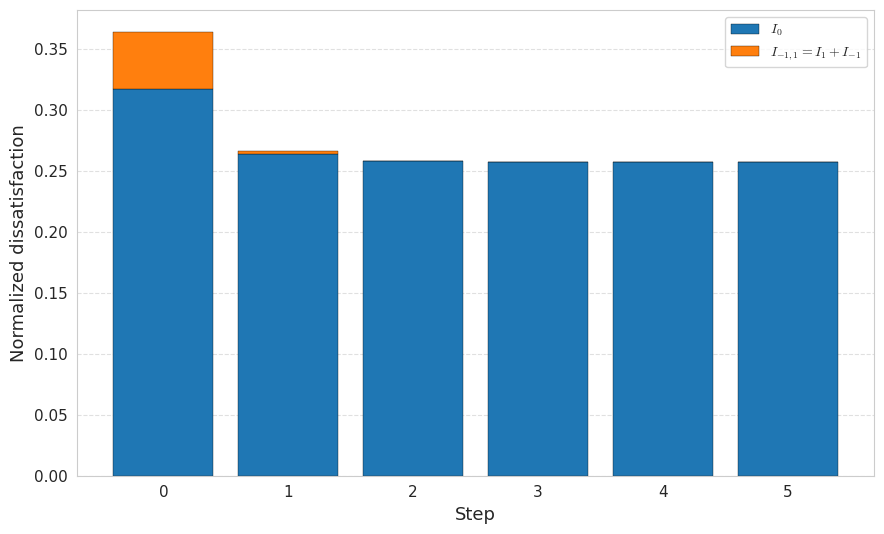

Figura guardada como:
- barras_apiladas_I_tau_0_N0_1200_normalizada.png
- barras_apiladas_I_tau_0_N0_1200_normalizada.pdf
- barras_apiladas_I_tau_0_N0_1200_normalizada.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
# ============================================================
# GRÁFICA LONGITUDINAL DE I = I_0 + I_{-1,1}
# Barras apiladas: I_0 abajo, I_{-1,1}=I_1+I_-1 arriba
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import zipfile

from google.colab import files

# ============================================================
# CONFIGURACIÓN GENERAL DE ESTILO PARA ARTÍCULO
# ============================================================

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.titlesize": 15,
    "axes.labelsize": 13,
    "legend.fontsize": 10,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "mathtext.fontset": "cm",
    "text.usetex": False
})

sns.set_style("whitegrid")


# ============================================================
# PARÁMETROS EDITABLES
# ============================================================

# Usar componentes normalizados o escalados
# False: grafica I_0, I_{-1,1} normalizados
# True: grafica 2T I_0, 2T I_{-1,1}
USAR_ESCALADO = False

# Para no saturar la figura si hay muchos pasos.
# Por ejemplo: 1 = todos los pasos, 5 = cada 5 pasos, 10 = cada 10 pasos.
CADA_N_PASOS = 1

# Si hay demasiados pasos, el código reduce automáticamente el número de barras.
MAX_BARRAS = 250

# Tamaño de la figura
FIGSIZE = (9, 5.5)

# Guardar en PNG y PDF
GUARDAR_FIGURAS = True


# ============================================================
# CARGAR ARCHIVO EXCEL
# ============================================================

print("Selecciona el archivo Excel con los datos longitudinales:")
uploaded = files.upload()

archivo_excel = list(uploaded.keys())[0]

print(f"\nArchivo cargado: {archivo_excel}")

xls = pd.ExcelFile(archivo_excel)

if "Todos_los_pasos" in xls.sheet_names:
    hoja = "Todos_los_pasos"
else:
    hoja = xls.sheet_names[0]
    print(f"No se encontró la hoja 'Todos_los_pasos'. Se usará la hoja '{hoja}'.")

df = pd.read_excel(archivo_excel, sheet_name=hoja)

print(f"Hoja leída: {hoja}")
print(f"Filas leídas: {len(df)}")
display(df.head())


# ============================================================
# PREPARAR DATOS
# ============================================================

# Asegurar que exista N0.
# En tus códigos anteriores, N2 representa N0.
if "N0" not in df.columns:
    if "N2" in df.columns:
        df["N0"] = df["N2"]
    else:
        df["N0"] = np.nan

# Asegurar que exista I_{-1,1} = I_1 + I_-1
if "I_extremos" not in df.columns:
    if ("I_1" in df.columns) and ("I_-1" in df.columns):
        df["I_extremos"] = df["I_1"] + df["I_-1"]
    else:
        raise ValueError("No se encontraron las columnas 'I_1' e 'I_-1'.")

# Asegurar que exista I total normalizado
if "I_total_norm" not in df.columns:
    if "I_0" in df.columns:
        df["I_total_norm"] = df["I_0"] + df["I_extremos"]
    else:
        raise ValueError("No se encontró la columna 'I_0'.")

# Componentes escalados por 2T, si se desea graficar I escalada
if "I_0_escalado" not in df.columns:
    if ("T_contacts" in df.columns) and ("I_0" in df.columns):
        df["I_0_escalado"] = 2 * df["T_contacts"] * df["I_0"]

if "I_extremos_escalado" not in df.columns:
    if ("T_contacts" in df.columns) and ("I_extremos" in df.columns):
        df["I_extremos_escalado"] = 2 * df["T_contacts"] * df["I_extremos"]

# Ordenar por paso
df = df.sort_values("step").reset_index(drop=True)

# Reducir cantidad de barras si hay muchos pasos
n_pasos = len(df)

if CADA_N_PASOS > 1:
    df_plot = df[df["step"] % CADA_N_PASOS == 0].copy()
else:
    df_plot = df.copy()

if len(df_plot) > MAX_BARRAS:
    salto_auto = int(np.ceil(len(df_plot) / MAX_BARRAS))
    df_plot = df_plot.iloc[::salto_auto, :].copy()
    print(f"Hay muchos pasos. Se graficará una barra cada {salto_auto} filas aproximadamente.")

# Elegir columnas según escala
if USAR_ESCALADO:
    col_I0 = "I_0_escalado"
    col_Iext = "I_extremos_escalado"
    ylabel = r"Scaled dissatisfaction"
    titulo_escala = r"scaled components"
else:
    col_I0 = "I_0"
    col_Iext = "I_extremos"
    ylabel = r"Normalized dissatisfaction"
    titulo_escala = r"normalized components"

# Verificar columnas necesarias
for col in ["step", col_I0, col_Iext]:
    if col not in df_plot.columns:
        raise ValueError(f"No se encontró la columna requerida: {col}")

# Extraer tau y N0 para el título
tau_val = df["tol"].iloc[0] if "tol" in df.columns else None
N0_val = df["N0"].iloc[0] if "N0" in df.columns else None

N1_val = df["N1"].iloc[0] if "N1" in df.columns else None
Nm1_val = df["N3"].iloc[0] if "N3" in df.columns else None


# ============================================================
# GRÁFICA DE BARRAS APILADAS
# ============================================================

fig, ax = plt.subplots(figsize=FIGSIZE)

x = np.arange(len(df_plot))

ax.bar(
    x,
    df_plot[col_I0],
    label=r"$I_0$",
    edgecolor="black",
    linewidth=0.25
)

ax.bar(
    x,
    df_plot[col_Iext],
    bottom=df_plot[col_I0],
    label=r"$I_{-1,1}=I_1+I_{-1}$",
    edgecolor="black",
    linewidth=0.25
)

# Etiquetas del eje x
steps = df_plot["step"].astype(int).values

# Etiquetas del eje x
steps = df_plot["step"].astype(int).values

# Mostrar todos los pasos
ax.set_xticks(x)
ax.set_xticklabels(steps)

ax.set_xlabel(r"Step")
ax.set_ylabel(ylabel)

if tau_val is not None and N0_val is not None and N1_val is not None and Nm1_val is not None:
    title = (
        rf"Longitudinal evolution of $I=I_0+I_{{-1,1}}$, "
        rf"$\tau={tau_val}$, "
        rf"$N_0={int(N0_val)}$, "
        rf"$N_1=N_{{-1}}={int(N1_val)}$"
    )
elif tau_val is not None and N0_val is not None:
    title = (
        rf"Longitudinal evolution of $I=I_0+I_{{-1,1}}$, "
        rf"$\tau={tau_val}$, "
        rf"$N_0={int(N0_val)}$"
    )
else:
    title = rf"Longitudinal evolution of $I=I_0+I_{{-1,1}}$"

#ax.set_title(title)



ax.legend(frameon=True)
ax.grid(axis="y", linestyle="--", alpha=0.6)
ax.grid(axis="x", visible=False)

plt.tight_layout()

plt.show()


# ============================================================
# GUARDAR FIGURA
# ============================================================

if GUARDAR_FIGURAS:
    tau_str = str(tau_val).replace(".", "_") if tau_val is not None else "NA"
    N0_str = str(int(N0_val)) if not pd.isna(N0_val) else "NA"

    escala_str = "escalada" if USAR_ESCALADO else "normalizada"

    nombre_base = f"barras_apiladas_I_tau_{tau_str}_N0_{N0_str}_{escala_str}"

    archivo_png = nombre_base + ".png"
    archivo_pdf = nombre_base + ".pdf"
    archivo_zip = nombre_base + ".zip"

    fig.savefig(archivo_png, dpi=300, bbox_inches="tight")
    fig.savefig(archivo_pdf, bbox_inches="tight")

    with zipfile.ZipFile(archivo_zip, "w") as zipf:
        zipf.write(archivo_png)
        zipf.write(archivo_pdf)

    print(f"Figura guardada como:")
    print(f"- {archivo_png}")
    print(f"- {archivo_pdf}")
    print(f"- {archivo_zip}")

    files.download(archivo_zip)